In [ ]:
import sys
from pathlib import Path
from pyprojroot import here

sys.path.append(str(here()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.config import cfg
from src.my_utils import set_seed

set_seed(cfg.general.seed)
train_path = Path(cfg.paths.train)
test_path = Path(cfg.paths.test)
df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

### First look
df_train.head()
df_test.head()
print(df_train.columns, end="\n\n")
print(df_test.columns, end="\n\n")
print("Columns diff:", set(df_train.columns) - set(df_test.columns))

# sizes
print("train shape: ", df_train.shape)
print("test shape: ", df_test.shape)

df_train.info()

df_test.info()
df_train["Pclass"] = df_train["Pclass"].astype(str)
df_test["Pclass"] = df_test["Pclass"].astype(str)
# числовые признаки, часть из них на самом деле категориальные
df_train.describe(include=["int64", "float64"])

df_test.describe(include=["int64", "float64"])
# категориальные признаки
df_train.describe(include=["str"])

df_test.describe(include=["str"])

# [
#     "PassengerId",  # ! отбросить
#     "Survived",  # * целевая переменная (bool)
#     "Pclass",  # класс билета (cat)
#     "Name",  # ? фио (и титулы), ПО СУТИ БОЛЬШАЯ СТРОКА
#     "Sex",  # пол (cat)
#     "Age",  # ? пока num, но может cat
#     "SibSp",  # братья, сестры, сводные или супруги (num)
#     "Parch",  # родители или дети (num)
#     "Ticket",  # ? билет и какие-то символы, ТОЖЕ БОЛЬШАЯ СТРОКА
#     "Fare",  # стоимость билета (num)
#     "Cabin",  # ? номер каюты (cat или num)
#     "Embarked",  # порт (cat)
# ]

print(df_train["Name"].nunique())
print(df_train["Ticket"].nunique())  # не все уникальные
df_train["Ticket"].value_counts()
df_train[df_train["Ticket"] == "347082"]  # семья
df_train[df_train["Ticket"] == "1601"]  # знакомые?

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

Columns diff: {'Survived'}
train shape:  (891, 12)
test shape:  (418, 11)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str 

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
74,75,1,3,"Bing, Mr. Lee",male,32.0,0,0,1601,56.4958,NaN,S
169,170,0,3,"Ling, Mr. Lee",male,28.0,0,0,1601,56.4958,NaN,S
509,510,1,3,"Lang, Mr. Fang",male,26.0,0,0,1601,56.4958,NaN,S
643,644,1,3,"Foo, Mr. Choong",male,NaN,0,0,1601,56.4958,NaN,S
692,693,1,3,"Lam, Mr. Ali",male,NaN,0,0,1601,56.4958,NaN,S
826,827,0,3,"Lam, Mr. Len",male,NaN,0,0,1601,56.4958,NaN,S
838,839,1,3,"Chip, Mr. Chang",male,32.0,0,0,1601,56.4958,NaN,S


In [15]:
### Nan
temp = df_train.isna().mean().sort_values(ascending=False)
temp[temp > 0]


Cabin       0.771044
Age         0.198653
Embarked    0.002245
dtype: float64

In [ ]:
df_train[df_train["Cabin"].isna()]


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
884,885,0,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,7.0500,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


In [ ]:
df_train["Cabin"].value_counts()


Cabin
G6             4
C23 C25 C27    4
B96 B98        4
F33            3
E101           3
              ..
E17            1
A24            1
C50            1
B42            1
C148           1
Name: count, Length: 147, dtype: int64

In [ ]:
df_train[df_train["Cabin"] == "F33"]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
66,67,1,2,"Nye, Mrs. (Elizabeth Ramell)",female,29.0,0,0,C.A. 29395,10.5,F33,S
345,346,1,2,"Brown, Miss. Amelia ""Mildred""",female,24.0,0,0,248733,13.0,F33,S
516,517,1,2,"Lemore, Mrs. (Amelia Milley)",female,34.0,0,0,C.A. 34260,10.5,F33,S


In [ ]:
df_train["Cabin_letters"] = df_train["Cabin"].str.replace(
    r"[^a-zA-Zа-яА-Я]", "", regex=True
)

In [ ]:
df_train["Cabin_letters"].value_counts()

Cabin_letters
C       51
B       36
E       32
D       32
A       15
F        9
BB       7
G        4
CCC      4
CC       4
FG       3
BBBB     2
BBB      2
DD       1
FE       1
T        1
Name: count, dtype: int64

In [21]:
def simple_countplot(
    data: pd.DataFrame, x: str, hue: str = "Survived", palette: str = "Set2"
):
    fig, ax = plt.subplots(figsize=(7, 4), layout="constrained")
    g = sns.countplot(data=data, x=x, hue=hue, palette=palette)
    g.set(xlabel=x, ylabel="Count", title=f"{x} effect on {hue}")

    for container in ax.containers:
        ax.bar_label(container, fmt="%.0f", padding=3, fontsize=9)

    plt.show()

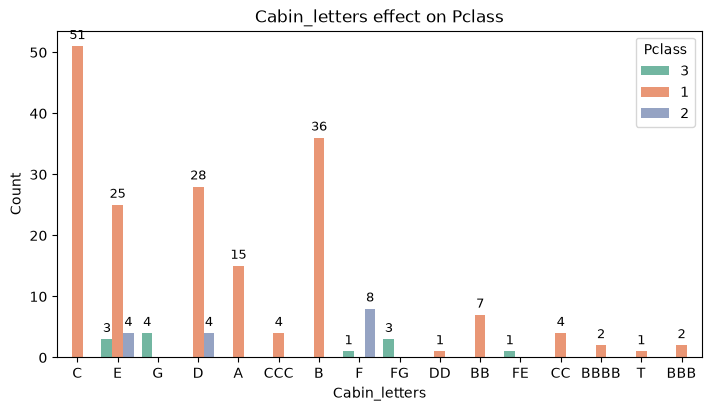

In [ ]:
simple_countplot(df_train, "Cabin_letters", hue="Pclass")

# tickets

In [23]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Cabin_letters
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,NaN
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,NaN
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,C
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,NaN


In [ ]:
df_train["Fare"].describe()


count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

In [ ]:
temp = df_train.groupby(by="Pclass")["Fare"].agg(["min", "max", "mean", "median"])
temp

,min,max,mean,median
Pclass,,,,
1,0.0,512.3292,84.154687,60.2875
2,0.0,73.5000,20.662183,14.2500
3,0.0,69.5500,13.675550,8.0500


In [ ]:
def cv_result_nn(
    model_nn,
    X_train,
    y_train,
    cv_splitter,
    preprocessor,
    best_epochs,  # Передаем число эпох, найденное на Шаге 1
    fit_params=None,
):
    fit_params = fit_params or {}

    # Клонируем базовую модель и жестко фиксируем число эпох
    # Также отключаем внутренний сплит skorch (train_split=None), так как CV контролируется внешне
    model_fixed = clone(model_nn)
    model_fixed.set_params(max_epochs=best_epochs, train_split=None, callbacks=[])

    model_pipe = Pipeline([("preprocessor", preprocessor), ("model", model_fixed)])

    fitted_models = []
    oof_preds = np.zeros(len(X_train), dtype=int)
    tr_scores = []
    val_scores = []

    # Проходим по фолдам вашей кросс-валидации (например, StratifiedKFold)
    for train_idx, val_idx in cv_splitter.split(X_train, y_train):
        # Отрезаем фолды (поддерживает и pandas, и numpy массивы)
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        fold_pipe = clone(model_pipe)

        # Обучаем модель на текущем фолде целиком на протяжении best_epochs
        fold_pipe.fit(X_tr, y_tr, **fit_params)

        fold_preds_tr = fold_pipe.predict(X_tr)
        fold_preds_val = fold_pipe.predict(X_val)

        oof_preds[val_idx] = fold_preds_val
        fitted_models.append(fold_pipe)

        tr_scores.append(accuracy_score(y_tr, fold_preds_tr))
        val_scores.append(accuracy_score(y_val, fold_preds_val))

    oof_accuracy = accuracy_score(y_train, oof_preds)

    metrics = pd.DataFrame(
        [
            {
                "TRAIN_acc_MEAN": np.mean(tr_scores),
                "TRAIN_acc_STD": np.std(tr_scores),
                "VAL_acc_MEAN": np.mean(val_scores),
                "VAL_acc_STD": np.std(val_scores),
                "OOF_acc": oof_accuracy,
            }
        ]
    )

    return fitted_models, oof_preds, metrics
